##### 9. Avaliação dos Modelos para API

Esta etapa tem como objetivo avaliar o desempenho dos modelos treinados utilizando exclusivamente atributos extraídos das URLs.

Foram analisadas métricas de classificação, matrizes de confusão e curvas ROC, visando verificar a viabilidade da detecção de phishing em cenários de aplicação em tempo real, como APIs e sistemas leves de monitoramento.

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [3]:
# Carregamento dos dados para API (versão com URL)

X_test = pd.read_csv("../data/output_API/test_train/X_test_url.csv")

y_test = pd.read_csv(
    "../data/output_API/test_train/y_test_url.csv"
).squeeze()

X_test_scaled = pd.read_csv(
    "../data/output_API/test_train/X_test_scaled_url.csv"
)

In [4]:
# Carregamento dos modelos

log_model = joblib.load(
    "../data/output_API/models/log_model_url.pkl"
)

tree_model = joblib.load(
    "../data/output_API/models/tree_model_url.pkl"
)

rf_model = joblib.load(
    "../data/output_API/models/rf_model_url.pkl"
)

In [5]:
# Predição

# Regressão Logística
y_pred_log = log_model.predict(
    X_test_scaled
)

# Árvore de Decisão
y_pred_tree = tree_model.predict(
    X_test
)

# Random Forest
y_pred_rf = rf_model.predict(
    X_test
)


C:\Users\u513127\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [7]:
# Métricas

def avaliar_modelo(nome, y_true, y_pred):

    print(f"\n===== {nome} =====")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )

    print(
        "F1-Score:",
        f1_score(y_true, y_pred)
    )

In [8]:
avaliar_modelo(
    "Regressão Logística",
    y_test,
    y_pred_log
)

avaliar_modelo(
    "Decision Tree",
    y_test,
    y_pred_tree
)

avaliar_modelo(
    "Random Forest",
    y_test,
    y_pred_rf
)


===== Regressão Logística =====
Accuracy: 0.85
Precision: 0.8314393939393939
Recall: 0.878
F1-Score: 0.8540856031128404

===== Decision Tree =====
Accuracy: 0.8695
Precision: 0.851569933396765
Recall: 0.895
F1-Score: 0.8727450024378351

===== Random Forest =====
Accuracy: 0.9
Precision: 0.8861003861003861
Recall: 0.918
F1-Score: 0.9017681728880157


| Modelo              | Accuracy | Precision | Recall | F1-Score |
| ------------------- | -------- | --------- | ------ | -------- |
| Regressão Logística | 0.8500   | 0.8314    | 0.8780 | 0.8541   |
| Decision Tree       | 0.8695   | 0.8516    | 0.8950 | 0.8727   |
| Random Forest       | 0.9000   | 0.8861    | 0.9180 | 0.9018   |


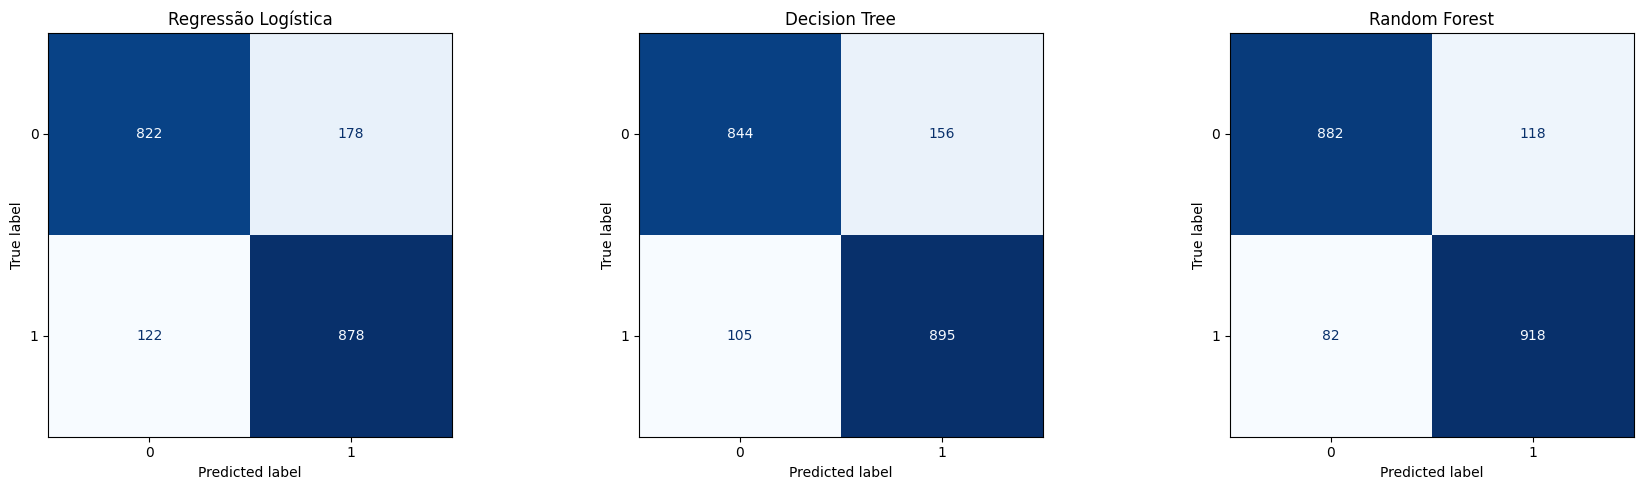

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regressão Logística
cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log
).plot(
    ax=axes[0],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[0].set_title("Regressão Logística")


# Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree
).plot(
    ax=axes[1],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[1].set_title("Decision Tree")


# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot(
    ax=axes[2],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[2].set_title("Random Forest")


plt.tight_layout()

plt.show()

| Modelo              | VP  | FN  | FP  | VN  |
| ------------------- | --- | --- | --- | --- |
| Regressão Logística | 822 | 178 | 122 | 878 |
| Decision Tree       | 844 | 156 | 105 | 895 |
| Random Forest       | 882 | 118 | 82  | 918 |


Os resultados demonstram que atributos diretamente extraídos das URLs apresentam elevada capacidade discriminatória para detecção de phishing, mesmo sem utilização de informações estruturais da página HTML.

O modelo Random Forest apresentou o melhor desempenho geral, alcançando 90% de acurácia e recall superior a 91%, indicando elevada capacidade de identificação de URLs maliciosas.

Os resultados obtidos reforçam a viabilidade de aplicações em tempo real baseadas exclusivamente em análise de URLs, como APIs de classificação automática e sistemas leves de monitoramento.


In [10]:
# Curva ROC - Regressão Logística
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Curva ROC - Decision Tree
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

# Curva ROC - Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

C:\Users\u513127\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


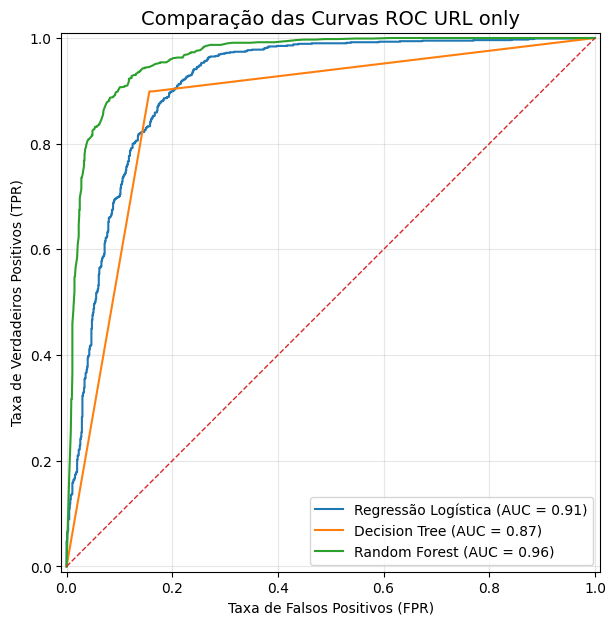

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))

# Regressão Logística
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name='Regressão Logística',
    ax=ax
)

# Decision Tree
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_tree,
    name='Decision Tree',
    ax=ax
)

# Random Forest
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name='Random Forest',
    ax=ax
)

# Linha aleatória
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1
)

ax.set_title(
    "Comparação das Curvas ROC URL only",
    fontsize=14
)

ax.set_xlabel(
    "Taxa de Falsos Positivos (FPR)"
)

ax.set_ylabel(
    "Taxa de Verdadeiros Positivos (TPR)"
)

ax.grid(alpha=0.3)

plt.show()

In [12]:
# Cálculo da AUC - Regressão Logística
auc_log = roc_auc_score(y_test, y_prob_log)

# Cálculo da AUC - Decision Tree
auc_tree = roc_auc_score(y_test, y_prob_tree)

# Cálculo da AUC - Random Forest
auc_rf = roc_auc_score(y_test, y_prob_rf)

In [13]:
print(f"AUC - Regressão Logística: {auc_log:.4f}")

print(f"AUC - Decision Tree: {auc_tree:.4f}")

print(f"AUC - Random Forest: {auc_rf:.4f}")

AUC - Regressão Logística: 0.9143
AUC - Decision Tree: 0.8708
AUC - Random Forest: 0.9629


A ROC-AUC mede a probabilidade do modelo ranquear uma URL phishing acima de uma legítima. Então, 0.9629 ≈ 96.3% de capacidade discriminatória.

Dessa forma, os resultados obtidos evidenciam que características estruturais da URL são suficientes para capturar padrões relevantes associados a ataques de phishing, tornando viável a implementação de sistemas leves e aplicações em tempo real, como APIs de detecção automática.